In [2]:
# Conectar google colab a Drive
from google.colab import drive
drive.mount('/MyDrive/')

Mounted at /MyDrive/


In [3]:
#Cargado de datos
import csv
import pandas as pd
import numpy as np
import io
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.base import TransformerMixin
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Cargar datos de Hospitalizados
df_SEG_COV_pred = pd.read_csv('/MyDrive/MyDrive/TB_SEGUIM_COVID19_preprocesado.csv', encoding='utf8', delimiter=',')

In [4]:
from sklearn.cluster import KMeans

features = df_SEG_COV_pred[[
    'evolucion_alta_1', 'evolucion_defuncion_1', 'evolucion_desfavorable_1', 'evolucion_estacionario_1', 'evolucion_favorable_1', 'evolucion_referido_1',
    'con_oxigeno_1', 'con_ventilacion_1', 'esta_uci_1', 'esta_ucin_1',
    'evolucion_alta_2', 'evolucion_defuncion_2', 'evolucion_desfavorable_2', 'evolucion_estacionario_2', 'evolucion_favorable_2', 'evolucion_referido_2',
    'con_oxigeno_2', 'con_ventilacion_2', 'esta_uci_2', 'esta_ucin_2',
    'evolucion_alta_3', 'evolucion_defuncion_3', 'evolucion_desfavorable_3', 'evolucion_estacionario_3', 'evolucion_favorable_3', 'evolucion_referido_3',
    'con_oxigeno_3', 'con_ventilacion_3', 'esta_uci_3', 'esta_ucin_3',
    'evolucion_alta_4', 'evolucion_defuncion_4', 'evolucion_desfavorable_4', 'evolucion_estacionario_4', 'evolucion_favorable_4', 'evolucion_referido_4',
    'con_oxigeno_4', 'con_ventilacion_4', 'esta_uci_4', 'esta_ucin_4'
]]

df_SEG_COV_pred.head(100)

,evolucion_alta_1,evolucion_defuncion_1,evolucion_desfavorable_1,evolucion_estacionario_1,evolucion_favorable_1,evolucion_referido_1,con_oxigeno_1,con_ventilacion_1,esta_uci_1,esta_ucin_1,...,evolucion_alta_4,evolucion_defuncion_4,evolucion_desfavorable_4,evolucion_estacionario_4,evolucion_favorable_4,evolucion_referido_4,con_oxigeno_4,con_ventilacion_4,esta_uci_4,esta_ucin_4
0,False,False,True,False,False,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
1,False,False,False,True,False,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
2,False,False,True,False,False,False,0,0,0,0,...,False,True,False,False,False,False,1,0,0,0
3,False,False,True,False,False,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
4,False,False,False,False,True,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,False,False,False,True,False,False,1,0,0,0,...,False,True,False,False,False,False,1,0,0,0
96,False,False,False,False,True,False,0,0,0,0,...,True,False,False,False,False,False,0,0,0,0
97,False,False,False,True,False,False,1,0,0,0,...,True,False,False,False,False,False,0,0,0,0
98,False,False,False,True,False,False,0,0,0,0,...,True,False,False,False,False,False,0,0,0,0


In [5]:
# Rellenar datos faltantes con 0
df_SEG_COV_pred.fillna(0, inplace=True)

# Estandarización de los datos
scaler = preprocessing.StandardScaler()
scaled_features = scaler.fit_transform(features)

for col in df_SEG_COV_pred.columns:
  print(col)

evolucion_alta_1
evolucion_defuncion_1
evolucion_desfavorable_1
evolucion_estacionario_1
evolucion_favorable_1
evolucion_referido_1
con_oxigeno_1
con_ventilacion_1
esta_uci_1
esta_ucin_1
evolucion_alta_2
evolucion_defuncion_2
evolucion_desfavorable_2
evolucion_estacionario_2
evolucion_favorable_2
evolucion_referido_2
con_oxigeno_2
con_ventilacion_2
esta_uci_2
esta_ucin_2
evolucion_alta_3
evolucion_defuncion_3
evolucion_desfavorable_3
evolucion_estacionario_3
evolucion_favorable_3
evolucion_referido_3
con_oxigeno_3
con_ventilacion_3
esta_uci_3
esta_ucin_3
evolucion_alta_4
evolucion_defuncion_4
evolucion_desfavorable_4
evolucion_estacionario_4
evolucion_favorable_4
evolucion_referido_4
con_oxigeno_4
con_ventilacion_4
esta_uci_4
esta_ucin_4


  * Imprimiendo el DataFrame df_SEG_COV_pred que contiene las variables de evolución y tratamiento de pacientes COVID-19
  * Cada fila representa un paciente, y cada columna representa una variable específica en una de las cuatro observaciones
  * Los valores de las columnas indican el estado del paciente en términos de evolución (True/False) y tratamientos (1/0)

In [6]:
df_SEG_COV_pred

,evolucion_alta_1,evolucion_defuncion_1,evolucion_desfavorable_1,evolucion_estacionario_1,evolucion_favorable_1,evolucion_referido_1,con_oxigeno_1,con_ventilacion_1,esta_uci_1,esta_ucin_1,...,evolucion_alta_4,evolucion_defuncion_4,evolucion_desfavorable_4,evolucion_estacionario_4,evolucion_favorable_4,evolucion_referido_4,con_oxigeno_4,con_ventilacion_4,esta_uci_4,esta_ucin_4
0,False,False,True,False,False,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
1,False,False,False,True,False,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
2,False,False,True,False,False,False,0,0,0,0,...,False,True,False,False,False,False,1,0,0,0
3,False,False,True,False,False,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
4,False,False,False,False,True,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12760,False,False,False,True,False,False,0,0,0,0,...,True,False,False,False,False,False,1,0,0,0
12761,False,False,False,True,False,False,0,0,0,0,...,True,False,False,False,False,False,0,0,0,0
12762,False,False,False,True,False,False,1,0,0,0,...,True,False,False,False,False,False,1,0,0,0
12763,False,False,False,True,False,False,1,1,0,0,...,True,False,False,False,False,False,1,1,0,0


**APLICANDO EL MÉTODO DEL CODO PARA DETERMINAR EL NÚMERO ÓPTIMO DE CLUSTERS**

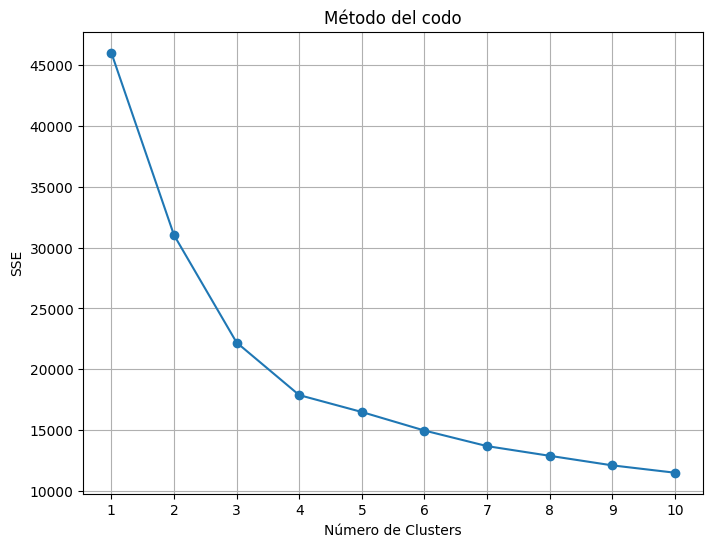

Número de clusters: 1, SSE: 45997.042694867385
Número de clusters: 2, SSE: 31027.510377679784
Número de clusters: 3, SSE: 22202.901743979703
Número de clusters: 4, SSE: 17884.237519137285
Número de clusters: 5, SSE: 16495.76068700442
Número de clusters: 6, SSE: 14972.932152520982
Número de clusters: 7, SSE: 13693.945591428563
Número de clusters: 8, SSE: 12898.31686980135
Número de clusters: 9, SSE: 12113.58396286265
Número de clusters: 10, SSE: 11510.148198689958


In [7]:
import matplotlib.pyplot as plt

# Método del codo para encontrar numero de clusters
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    sse.append(kmeans.inertia_)

# Graficar método del codo
plt.figure(figsize=(8, 6))
plt.plot(K, sse, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('SSE')
plt.title('Método del codo')
plt.grid(True)
plt.xticks(K)
plt.show()

# Imprimir valores
for k, score in zip(K, sse):
    print(f'Número de clusters: {k}, SSE: {score}')

In [8]:
# Aplicando KMeans con el número óptimo de clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)

# Añadir los clusters al dataframe original
df_SEG_COV_pred['Cluster'] = clusters

# Descripción de los clusters
for cluster in range(optimal_clusters):
    print(f'Cluster {cluster}')
    print(df_SEG_COV_pred[df_SEG_COV_pred['Cluster'] == cluster].describe())

Cluster 0
       con_oxigeno_1  con_ventilacion_1   esta_uci_1  esta_ucin_1  \
count    3497.000000        3497.000000  3497.000000  3497.000000   
mean        0.910781           0.001144     0.010866     0.037175   
std         0.285101           0.033806     0.103689     0.189217   
min         0.000000           0.000000     0.000000     0.000000   
25%         1.000000           0.000000     0.000000     0.000000   
50%         1.000000           0.000000     0.000000     0.000000   
75%         1.000000           0.000000     0.000000     0.000000   
max         1.000000           1.000000     1.000000     1.000000   

       con_oxigeno_2  con_ventilacion_2   esta_uci_2  esta_ucin_2  \
count    3497.000000             3497.0  3497.000000  3497.000000   
mean        0.944238                0.0     0.012582     0.042322   
std         0.229495                0.0     0.111478     0.201352   
min         0.000000                0.0     0.000000     0.000000   
25%         1.000000   

**APLICANDO EL ALGORITMO DE K-MEANS**

In [9]:
# Aplicando el modelo KMeans con 3 clusters
model = KMeans(n_clusters = 3, n_init=10)
# Ajustando el modelo a los datos del DataFrame
model.fit(df_SEG_COV_pred)

KMeans(n_clusters=3, n_init=10)

In [10]:
# Etiquetas de cluster asignadas a cada instancia
model.labels_

array([2, 0, 2, ..., 0, 0, 0], dtype=int32)

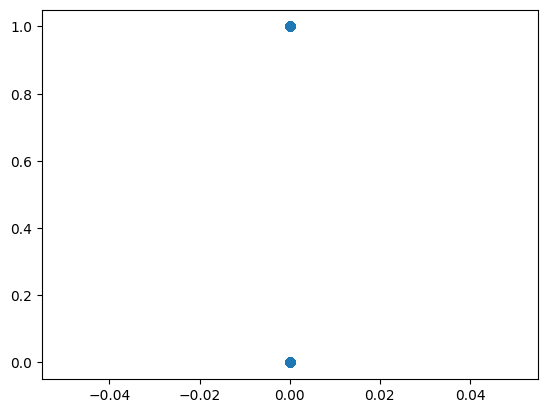

In [20]:
# Visualizacion de clusters
plt.scatter(df_SEG_COV_pred.evolucion_alta_1, df_SEG_COV_pred.evolucion_favorable_1)

Text(0.5, 1.0, 'Clasificación REAL')

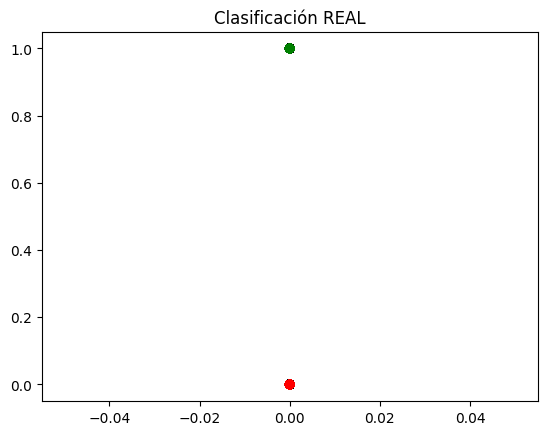

In [21]:
# Visualizacion de clusters
colormap=np.array(['Red','green','blue','yellow'])

plt.scatter(df_SEG_COV_pred.evolucion_alta_1, df_SEG_COV_pred.evolucion_favorable_1, c = colormap[model.labels_])
plt.title('Clasificación REAL')

Se aplica nuevamente el algoritmo de KMeans y se visualizan los clusters

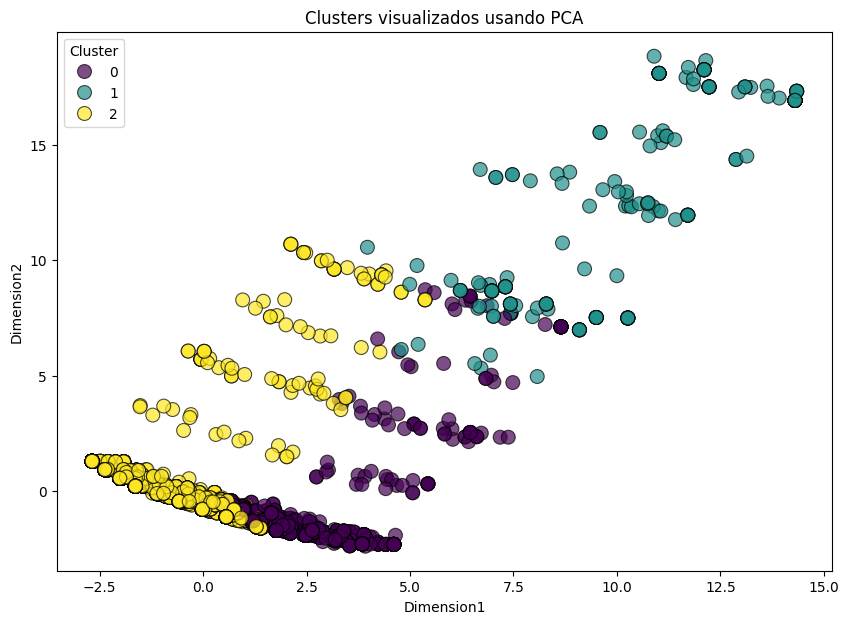

In [22]:
import seaborn as sns
from sklearn.decomposition import PCA

# Reducimps la dimensionalidad para visualización usando PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Creando un DataFrame para los componentes principales
df_pca = pd.DataFrame(pca_features, columns=['Dimension1', 'Dimension2'])
df_pca['Cluster'] = clusters

# Graficar los clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Dimension1', y='Dimension2', hue='Cluster', palette='viridis', data=df_pca, s=100, alpha=0.7, edgecolor='k')
plt.title('Clusters visualizados usando PCA')
plt.xlabel('Dimension1')
plt.ylabel('Dimension2')
plt.legend(title='Cluster')
plt.show()

**DESCRIPCIONES ESTADÍSTICAS DE COMBINACIONES CLAVE PARA LA ASISTENCIA RESPIRATORIA Y LA EVOLUCIÓN CLÍNICA**

Análisis estadístico de la asistencia respiratoria en pacientes con COVID-19

In [24]:
df_SEG_COV_pred[['con_oxigeno_1', 'con_ventilacion_1', 'con_oxigeno_2', 'con_ventilacion_2']].describe()

,con_oxigeno_1,con_ventilacion_1,con_oxigeno_2,con_ventilacion_2
count,12765.000000,12765.000000,12765.000000,12765.000000
mean,0.472699,0.011986,0.470819,0.014493
std,0.499274,0.108826,0.499167,0.119515
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


Análisis estadístico de Oxígeno y UCI en pacientes con COVID-19

In [25]:
df_SEG_COV_pred[['con_oxigeno_1', 'esta_uci_1', 'con_oxigeno_2', 'esta_uci_2']].describe()

,con_oxigeno_1,esta_uci_1,con_oxigeno_2,esta_uci_2
count,12765.000000,12765.000000,12765.000000,12765.000000
mean,0.472699,0.015511,0.470819,0.019193
std,0.499274,0.123579,0.499167,0.137209
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


Análisis estadístico de Ventilación y UCI en pacientes con COVID-19

In [26]:
df_SEG_COV_pred[['con_ventilacion_1', 'esta_uci_1', 'con_ventilacion_2', 'esta_uci_2']].describe()

,con_ventilacion_1,esta_uci_1,con_ventilacion_2,esta_uci_2
count,12765.000000,12765.000000,12765.000000,12765.000000
mean,0.011986,0.015511,0.014493,0.019193
std,0.108826,0.123579,0.119515,0.137209
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


Análisis estadístico de estado de UCI y evolución clínica en pacientes con COVID-19

In [27]:
df_SEG_COV_pred[['esta_uci_1', 'evolucion_alta_1', 'esta_uci_2', 'evolucion_alta_2']].describe()

,esta_uci_1,esta_uci_2
count,12765.000000,12765.000000
mean,0.015511,0.019193
std,0.123579,0.137209
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


Comparación de estados en diferentes etapas de asistencia respiratoria en pacientes con COVID-19

In [28]:
df_SEG_COV_pred[['con_oxigeno_1', 'con_oxigeno_2', 'con_oxigeno_3', 'con_ventilacion_1', 'con_ventilacion_2', 'con_ventilacion_3']].describe()

,con_oxigeno_1,con_oxigeno_2,con_oxigeno_3,con_ventilacion_1,con_ventilacion_2,con_ventilacion_3
count,12765.000000,12765.000000,12765.000000,12765.000000,12765.000000,12765.000000
mean,0.472699,0.470819,0.440423,0.011986,0.014493,0.016765
std,0.499274,0.499167,0.496457,0.108826,0.119515,0.128393
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
# Número de instancias en cada cluster
print(df_SEG_COV_pred['Cluster'].value_counts())

Cluster
2    9067
0    3497
1     201
Name: count, dtype: int64


Filtrado y análisis estadístico de cada cluster

In [35]:
cluster_0 = df_SEG_COV_pred[df_SEG_COV_pred['Cluster'] == 0]
cluster_0.describe()

,con_oxigeno_1,con_ventilacion_1,esta_uci_1,esta_ucin_1,con_oxigeno_2,con_ventilacion_2,esta_uci_2,esta_ucin_2,con_oxigeno_3,con_ventilacion_3,esta_uci_3,esta_ucin_3,con_oxigeno_4,con_ventilacion_4,esta_uci_4,esta_ucin_4,Cluster
count,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.0,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.0
mean,0.910781,0.001144,0.010866,0.037175,0.944238,0.0,0.012582,0.042322,0.960824,0.003717,0.013440,0.046039,0.915070,0.011724,0.020875,0.049185,0.0
std,0.285101,0.033806,0.103689,0.189217,0.229495,0.0,0.111478,0.201352,0.194042,0.060866,0.115166,0.209601,0.278817,0.107658,0.142986,0.216285,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0
50%,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0
75%,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [36]:
cluster_1 = df_SEG_COV_pred[df_SEG_COV_pred['Cluster'] == 1]
cluster_1.describe()

,con_oxigeno_1,con_ventilacion_1,esta_uci_1,esta_ucin_1,con_oxigeno_2,con_ventilacion_2,esta_uci_2,esta_ucin_2,con_oxigeno_3,con_ventilacion_3,esta_uci_3,esta_ucin_3,con_oxigeno_4,con_ventilacion_4,esta_uci_4,esta_ucin_4,Cluster
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.0
mean,0.825871,0.691542,0.502488,0.104478,0.800995,0.880597,0.646766,0.099502,0.810945,0.965174,0.706468,0.099502,0.800995,0.950249,0.696517,0.099502,1.0
std,0.380168,0.463010,0.501242,0.306643,0.400249,0.325072,0.479168,0.300083,0.392530,0.183796,0.456517,0.300083,0.400249,0.217973,0.460910,0.300083,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.0
50%,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.0
75%,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


In [37]:
cluster_2 = df_SEG_COV_pred[df_SEG_COV_pred['Cluster'] == 2]
cluster_2.describe()

,con_oxigeno_1,con_ventilacion_1,esta_uci_1,esta_ucin_1,con_oxigeno_2,con_ventilacion_2,esta_uci_2,esta_ucin_2,con_oxigeno_3,con_ventilacion_3,esta_uci_3,esta_ucin_3,con_oxigeno_4,con_ventilacion_4,esta_uci_4,esta_ucin_4,Cluster
count,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.0
mean,0.295908,0.001103,0.006507,0.024484,0.280909,0.000882,0.007831,0.027242,0.231499,0.000772,0.005404,0.027021,0.165215,0.000551,0.005294,0.027462,2.0
std,0.456475,0.033193,0.080408,0.154556,0.449468,0.029692,0.088148,0.162796,0.421814,0.027776,0.073318,0.162154,0.371395,0.023478,0.072571,0.163435,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
75%,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.0


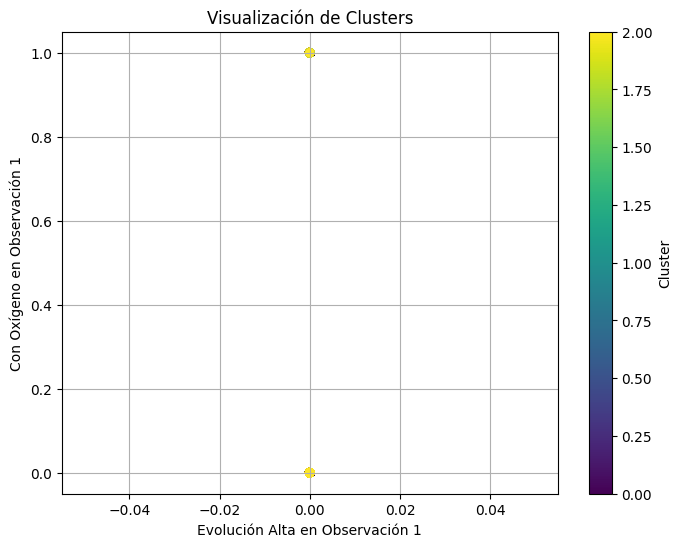

In [38]:
# Visualización de clusters
plt.figure(figsize=(8, 6))
plt.scatter(df_SEG_COV_pred['evolucion_alta_1'], df_SEG_COV_pred['con_oxigeno_1'], c=df_SEG_COV_pred['Cluster'], cmap='viridis')
plt.xlabel('Evolución Alta en Observación 1')
plt.ylabel('Con Oxígeno en Observación 1')
plt.title('Visualización de Clusters')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

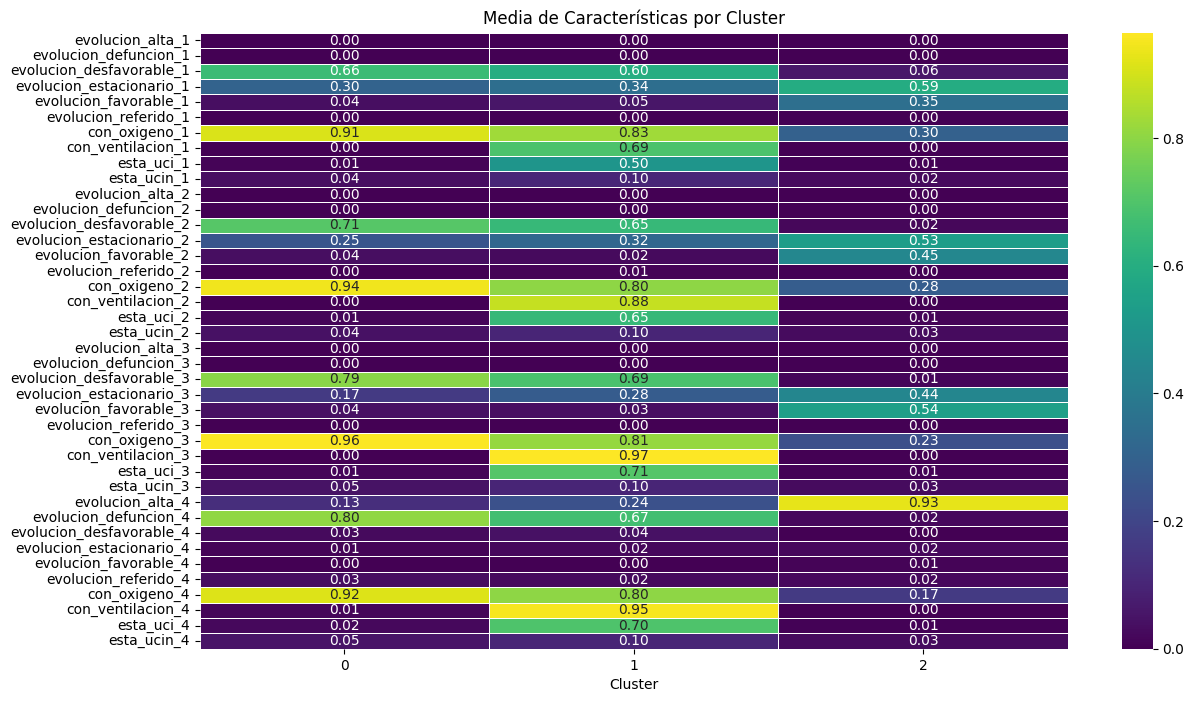

In [39]:
# Visualización de características por cluster
cluster_features = df_SEG_COV_pred.groupby('Cluster').mean()
cluster_features = cluster_features.transpose()

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_features, annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Media de Características por Cluster')
plt.show()